# Frozen Lake - Value Iteration and Policy Iteration

Dynamic programming methods for solving the Frozen Lake environment using value iteration and policy iteration.

In [3]:
# First import gymnasium (https://gymnasium.farama.org/)
!pip install gymnasium

## Create an environment instance

### <u>IMPORTANT</u>: You should read the [Gymnasium's Frozen Lake environment page](https://gymnasium.farama.org/environments/toy_text/frozen_lake/) very carefully. Make sure you understand all of the descriptions there.

Remember our grid is 8x8, therefore the state indices are from 0 to 63 (both inclusive) -- look under "Observation Space" on the page.

In [5]:
import gymnasium as gym
import numpy as np

# Create a FrozenLake 8x8 environment using Gymnasium
# (https://gymnasium.farama.org/environments/toy_text/frozen_lake/).
env = gym.make('FrozenLake-v1', desc=None, map_name="8x8", is_slippery=True, render_mode="ansi")

# (*) 10/16 update. This line is critically needed to access the state and the probabilities in the environment
#  due to the recent code update by Gymnasium.
env_unwrapped = env.unwrapped

# Reset the environment and display it (in ansi ascii)
env.reset()
print (env.render())  # wrap render() in print()


SFFFFFFF
FFFFFFFF
FFFHFFFF
FFFFFHFF
FFFHFFFF
FHHFFFHF
FHFFHFHF
FFFHFFFG



In [6]:
## Alternatively you can create a random map, as described in
## the FrozenLake documentation page.  It's commented out for now.

#from gymnasium.envs.toy_text.frozen_lake import generate_random_map

#env = gym.make('FrozenLake-v1', desc=generate_random_map(size=8))

In [7]:
# Make one (random) action
action = env.action_space.sample() # choose a random action
print (action)                     # print the action (its index)

next_state, reward, done, info, p= env.step(action) # take the action, inspect returned values

print (f'next_state={next_state}, reward={reward}, done={done}, info={info}, p={p}')
print (env.render())               # render/print the environment
print ()

0
next_state=0, reward=0.0, done=False, info=False, p={'prob': 0.3333333333333333}
  (Left)
SFFFFFFF
FFFFFFFF
FFFHFFFF
FFFFFHFF
FFFHFFFF
FHHFFFHF
FHFFHFHF
FFFHFFFG




In [8]:
print (env_unwrapped.s)  # current state (its 0-based index in a 1-D array)

0


## Inspect the environment

In [10]:
nS = env.observation_space.n    # number of states -- 8x8=64
nA = env.action_space.n         # number of actions -- four directions; 0:left, 1:down, 2:right, 3:up
print (f"number of states: {nS}\nnumber of actions: {nA}")

number of states: 64
number of actions: 4


Note that actions are 0-based integers. You can check in the Gymnasium source code (https://github.com/Farama-Foundation/Gymnasium/blob/d71a13588266256a4c900b5e0d72d10785816c3a/gymnasium/envs/toy_text/frozen_lake.py)

- 0: Move left
- 1: Move down
- 2: Move right
- 3: Move up

### All of the environment's probabilities are stored in 'env_unwrapped.P'.

It is a dictionary, keyed by the state index (e.g. env_unwrapped.P[0], env_unwrapped.P[1] etc.)

Then for each state, the value is a dictionary, <u>keyed by the actions (0-based). Then for each action, the value is a list, showing the <b>probability of transitioning into the next state, the index of the next state, reward, and True/False</b> (done=True if the next state is a Hole or the Goal)</u>.

### IMPORTANT: Description from the environment (from the Gymnasium page)

"is_slippery=True: If true the player will move in intended direction with probability of 1/3 else will move in either perpendicular direction with equal probability of 1/3 in both directions.

For example, if action is left and is_slippery is True, then:

- P(move left)=1/3
- P(move up)=1/3
- P(move down)=1/3
  
" Be sure to understand that. It's critical for completing the assignment.

In [13]:
# Probatilies from State 0 (the start state)
env_unwrapped.P[0]

{0: [(0.3333333333333333, 0, 0.0, False),
  (0.3333333333333333, 0, 0.0, False),
  (0.3333333333333333, 8, 0.0, False)],
 1: [(0.3333333333333333, 0, 0.0, False),
  (0.3333333333333333, 8, 0.0, False),
  (0.3333333333333333, 1, 0.0, False)],
 2: [(0.3333333333333333, 8, 0.0, False),
  (0.3333333333333333, 1, 0.0, False),
  (0.3333333333333333, 0, 0.0, False)],
 3: [(0.3333333333333333, 1, 0.0, False),
  (0.3333333333333333, 0, 0.0, False),
  (0.3333333333333333, 0, 0.0, False)]}

In [14]:
# Probatilies from State 62 (left of the Goal state).
# Notice some 'True' results (implying the goal is reached).
env_unwrapped.P[62]

{0: [(0.3333333333333333, 54, 0.0, True),
  (0.3333333333333333, 61, 0.0, False),
  (0.3333333333333333, 62, 0.0, False)],
 1: [(0.3333333333333333, 61, 0.0, False),
  (0.3333333333333333, 62, 0.0, False),
  (0.3333333333333333, 63, 1.0, True)],
 2: [(0.3333333333333333, 62, 0.0, False),
  (0.3333333333333333, 63, 1.0, True),
  (0.3333333333333333, 54, 0.0, True)],
 3: [(0.3333333333333333, 63, 1.0, True),
  (0.3333333333333333, 54, 0.0, True),
  (0.3333333333333333, 61, 0.0, False)]}

## ** Functions to create a fixed deterministic policy, and to run one experiment *** <u>Following the policy</u>*** for a given number of episodes

In [16]:
def generate_random_policy(num_actions, num_states, seed=None):
    """
    A policy is a 1D array of length # of states, where each element is a
    number between 0 (inclusive) and # of actions (exclusive) randomly chosen.
    If a specific seed is passed, the same numbers are genereated, while
    if the seed is None, the numbers are unpredictable every time.
    """
    rng = np.random.default_rng(seed)
    return rng.integers(low=0, high=num_actions, size=num_states)


def run_oneexperiment(env, policy, num_episodes, display=False):
    """
    Run one experiment, when agent follows a policy, for a given number of episodes.
    """
    # Count the number of goals made and getting stuck in a hole
    goals = 0
    holes = 0
    # Total rewards and steps
    total_rewards = 0
    total_goal_steps = 0

    for _ in range(num_episodes):
        # For each time,
        env.reset()
        done = False
        rewards = 0
        steps = 0

        if display:
            episode = [(env_unwrapped.env.s)] # initial state (in a tuple)

        while not done:
            # choose the action based on the policy
            state = env_unwrapped.s
            action = policy[state]  # (!) look up the policy and choose the action for the state

            # take the action
            next_state, reward, done, info, p = env.step(action)  # take the chosen action
            steps += 1

            # extend the episode
            if display:
                episode.append(tuple([action,next_state]))
            # accumulate rewards
            rewards += reward

        # Calculate stats
        total_rewards += rewards
        if reward == 1.0: # Goal, or env.s == 63
            goals += 1
            total_goal_steps += steps
        else:
            holes += 1

        # Display
        if display:
            print (env.render())

    # One experiment finished,
    return goals, holes, total_rewards, total_goal_steps

### * A utility function to display a 1D array/policy in a 2D array/grid *

In [18]:
import math

def display_policy(policy):
    side = int(math.sqrt(nS))  # assuming a square
    policy = policy.reshape((side, side))
    return policy

## One experiment run

The episode follows the policy (fixed). Episodes are executed 10000 times to get reliable probability estimates.

In [20]:
policy = generate_random_policy(nA, nS, 17) # change seed to a specific number, or None (default)
print ("*** Policy ***\n{}".format(display_policy(policy)))

num_episodes = 10000

goals, holes, total_rewards, total_goal_steps \
    = run_oneexperiment(env, policy, num_episodes)

percent_goal = goals / num_episodes
percent_hole = holes / num_episodes
mean_reward = total_rewards / num_episodes
mean_goal_steps = 0.0 if (goals == 0) else (total_goal_steps / goals)

print ("\n*** RESULTS ***:\nGoals: {:>5d}/{} = {:>7.3%}\nHoles: {:>5d}/{} = {:>7.3%}"
       .format(goals, num_episodes, percent_goal, holes, num_episodes, percent_hole))
print("mean reward:          {:.5f}\nmean goal steps:     {:.2f}".format(mean_reward, mean_goal_steps))

*** Policy ***
[[2 3 0 0 1 2 3 1]
 [0 0 1 1 3 1 2 2]
 [0 2 0 0 2 1 1 2]
 [0 0 2 3 2 3 1 0]
 [2 2 2 2 1 0 2 0]
 [1 0 2 1 1 2 0 1]
 [2 3 0 3 1 1 3 0]
 [0 1 2 3 1 1 3 3]]

*** RESULTS ***:
Goals:    29/10000 =  0.290%
Holes:  9971/10000 = 99.710%
mean reward:          0.00290
mean goal steps:     58.48


## Examine a few steps to ensure our understanding

In [22]:
env.reset()

for _ in range(5):
    action = env.action_space.sample()  # a random action
    print (action)       # print the action (0-based)
    env.step(action)     # take that actin in the current environment
    print (env.render()) # display the resulting environment

2
  (Right)
SFFFFFFF
FFFFFFFF
FFFHFFFF
FFFFFHFF
FFFHFFFF
FHHFFFHF
FHFFHFHF
FFFHFFFG

2
  (Right)
SFFFFFFF
FFFFFFFF
FFFHFFFF
FFFFFHFF
FFFHFFFF
FHHFFFHF
FHFFHFHF
FFFHFFFG

3
  (Up)
SFFFFFFF
FFFFFFFF
FFFHFFFF
FFFFFHFF
FFFHFFFF
FHHFFFHF
FHFFHFHF
FFFHFFFG

3
  (Up)
SFFFFFFF
FFFFFFFF
FFFHFFFF
FFFFFHFF
FFFHFFFF
FHHFFFHF
FHFFHFHF
FFFHFFFG

0
  (Left)
SFFFFFFF
FFFFFFFF
FFFHFFFF
FFFFFHFF
FFFHFFFF
FHHFFFHF
FHFFHFHF
FFFHFFFG



# Updated code: 
## PART 1 - Fixed policies:
### Created a function that runs the policy for 100 times with 10000 episodes, and we can measure how well it works on average.

In [24]:
def repeat_runs_for_policy(policy, repetitions=100, episode_count=10000):
    final_goals = [] # a list that stores no.of goals reached in each repetition
    avg_steps_for_goals = [] # average steps taken for reaching goal in each repetition

    for _ in range(repetitions): # loops over 100 times
        g_count, h_count, total_rewards, total_steps_to_goals = run_oneexperiment(env,policy, episode_count) # calling run_oneexperiment function
        final_goals.append(g_count) # no. of goals from this repetition
        if g_count > 0:  # if goal is reached we compute average steps for successful episodes else we assigned the value 0
            average_steps = total_steps_to_goals / g_count
        else:
            average_steps = 0  
        avg_steps_for_goals.append(average_steps)
    return final_goals, avg_steps_for_goals # returns list of no. of goals reached and avg steps taken to reach goal for each repetition


## Created 5 policies with different seed values and running it for 100 times using above function and then calculating the mean, std and percentage that reached goal and hole

In [26]:
seeds = [13, 37, 55, 62, 72]  # list of 5 different seed values
results_evaluation = [] # storing results for results comparision
episode_count = 10000
repetitions = 100
for s in seeds: # loop through each seed and generate a policy by calling generate_random_policy function
    policy = generate_random_policy(nA, nS, s)
    print(f"\nPolicy seed={s}")
    print ("*** Policy ***\n{}".format(display_policy(policy))) # printing the policies in 2d by calling display_policy
    goals_list, steps_list = repeat_runs_for_policy(policy, repetitions, episode_count) # evaluating a policy for 100 times by calling repeat_runs_for_policy function
    mean_goals = np.mean(goals_list) # calculating mean and standard deviation for goals and steps taken to reach goal 
    std_goals  = np.std(goals_list)
    mean_steps = np.mean(steps_list)
    std_steps  = np.std(steps_list)
    
    percent_goal = mean_goals / episode_count * 100
    percent_hole = 100 - percent_goal
    mean_reward = mean_goals / episode_count

    print("\n*** RESULTS ***:")
    print(f"Seed: {s}")
    print(f"Goals: {int(mean_goals):5d}/{episode_count} = {percent_goal:7.3f}%")
    print(f"Holes: {int(episode_count - mean_goals):5d}/{episode_count} = {percent_hole:7.3f}%")
    print(f"Mean reward:          {mean_reward:.5f}")
    print(f"Mean goal steps:     {mean_steps:.2f}")

    results_evaluation.append((s, policy, mean_goals, std_goals, mean_steps, std_steps, goals_list))  # storing results for comparison



Policy seed=13
*** Policy ***
[[3 3 3 3 0 3 3 1]
 [0 0 3 3 2 2 3 0]
 [3 3 0 3 3 1 1 3]
 [3 0 2 1 1 3 2 1]
 [3 2 3 0 3 3 2 1]
 [1 0 1 3 1 3 1 2]
 [1 2 1 3 2 0 3 2]
 [2 3 1 0 2 0 0 2]]

*** RESULTS ***:
Seed: 13
Goals:   432/10000 =   4.324%
Holes:  9567/10000 =  95.676%
Mean reward:          0.04324
Mean goal steps:     105.81

Policy seed=37
*** Policy ***
[[0 2 2 2 1 0 3 2]
 [1 1 3 1 3 3 0 0]
 [0 0 2 0 3 3 2 2]
 [3 0 1 0 2 2 3 0]
 [2 1 1 2 2 0 0 1]
 [1 2 0 2 1 1 1 3]
 [2 3 1 0 3 1 1 0]
 [1 3 0 0 2 1 2 3]]

*** RESULTS ***:
Seed: 37
Goals:     1/10000 =   0.016%
Holes:  9998/10000 =  99.984%
Mean reward:          0.00016
Mean goal steps:     57.26

Policy seed=55
*** Policy ***
[[3 3 2 3 0 0 3 0]
 [2 1 1 3 2 2 0 3]
 [3 0 2 1 1 1 1 2]
 [0 0 1 1 2 0 1 3]
 [3 2 1 2 3 3 2 1]
 [2 1 2 2 0 0 2 0]
 [2 1 3 2 3 2 2 0]
 [2 1 0 3 1 1 0 1]]

*** RESULTS ***:
Seed: 55
Goals:    21/10000 =   0.216%
Holes:  9978/10000 =  99.784%
Mean reward:          0.00216
Mean goal steps:     48.12

Policy seed=62

## Picking top 2 policies and then displaying the policies in 2D array and generating histograms


==== Top 2 Policies ====

1: Policy Seed 13
*** Policy ***
[[3 3 3 3 0 3 3 1]
 [0 0 3 3 2 2 3 0]
 [3 3 0 3 3 1 1 3]
 [3 0 2 1 1 3 2 1]
 [3 2 3 0 3 3 2 1]
 [1 0 1 3 1 3 1 2]
 [1 2 1 3 2 0 3 2]
 [2 3 1 0 2 0 0 2]]

2: Policy Seed 62
*** Policy ***
[[1 2 2 2 3 3 0 1]
 [0 2 2 3 0 2 3 3]
 [1 3 1 0 1 3 2 0]
 [1 0 1 1 1 0 3 1]
 [1 2 2 1 1 3 2 2]
 [1 3 2 1 1 2 2 0]
 [3 0 1 2 2 2 2 1]
 [3 0 1 2 3 3 3 3]]


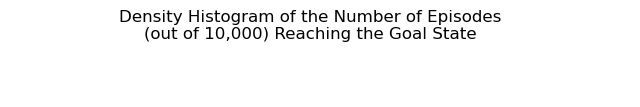

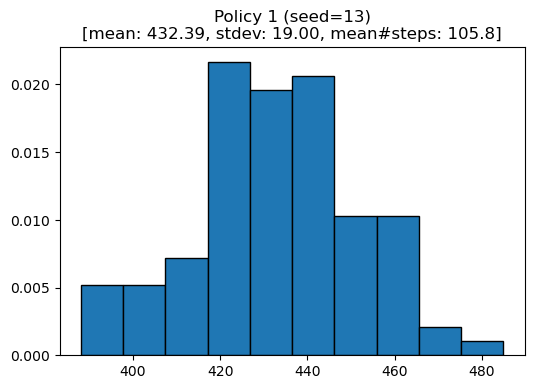

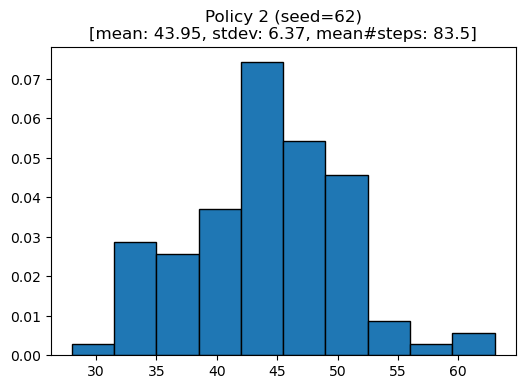

In [28]:
import matplotlib.pyplot as plt

top_two = sorted(results_evaluation, key=lambda x: x[2], reverse=True)[:2] # Sorting policies stored in result_evaluation in descending order and picking top 2
print("\n==== Top 2 Policies ====") # displaying the top 2 policies 
for i, item in enumerate(top_two):
    seedv, pol, mg, sg, ms, ss, goal_list = item 
    print(f"\n{i+1}: Policy Seed {seedv}")
    print("*** Policy ***\n{}".format(display_policy(pol)))


def plot_histogram(goals_list, seedv, mean_goals, std_goals, mean_steps, index): # Creating function to plot histogram
    plt.figure(figsize=(6, 4))
    plt.hist(goals_list, bins=10, edgecolor='black', density=True)
    plt.title(f"Policy {index+1} (seed={seedv})\n[mean: {mean_goals:.2f}, stdev: {std_goals:.2f}, mean#steps: {mean_steps:.1f}]")
    plt.show()
    
plt.figure(figsize=(8, 1))
plt.suptitle("Density Histogram of the Number of Episodes\n(out of 10,000) Reaching the Goal State\n") 
plt.axis("off")
for index, (best_seed, best_pol, best_mg, best_sg, best_ms, best_ss, stored_gl) in enumerate(top_two):
    plot_histogram(stored_gl, best_seed, best_mg, best_sg, best_ms, index)

## PART 2: Optimal Policy by Value Iteration
### Defining the function to check the terminal states and value iteration function to get optimal policy and values. Displaying the policy, values and histogram

*** Optimal Policy ***
[[3 2 2 2 2 2 2 2]
 [3 3 3 3 3 3 3 2]
 [0 0 0 0 2 3 3 2]
 [0 0 0 1 0 0 2 2]
 [0 3 0 0 2 1 3 2]
 [0 0 0 1 3 0 0 2]
 [0 0 1 0 0 0 0 2]
 [0 1 0 0 1 2 1 0]]

Final Values:
[[0.99823323 0.99831044 0.99842197 0.99854354 0.99866612 0.99878334
  0.99888814 0.99896483]
 [0.99821397 0.99827276 0.99836936 0.99848462 0.99860719 0.99873171
  0.99886003 0.99901008]
 [0.99683199 0.97525654 0.92389215 0.         0.85531987 0.94498778
  0.98096596 0.99909858]
 [0.99558378 0.93078946 0.79815834 0.47350677 0.62242089 0.
  0.94378534 0.99922649]
 [0.99451946 0.82168741 0.53991636 0.         0.53848733 0.61046658
  0.85120246 0.99938819]
 [0.99368164 0.         0.         0.16763079 0.38261111 0.44174102
  0.         0.99957664]
 [0.99310381 0.         0.19328935 0.1202984  0.         0.33216797
  0.         0.99978359]
 [0.99280901 0.72610605 0.45962631 0.         0.27738468 0.55477288
  0.77738468 0.        ]]


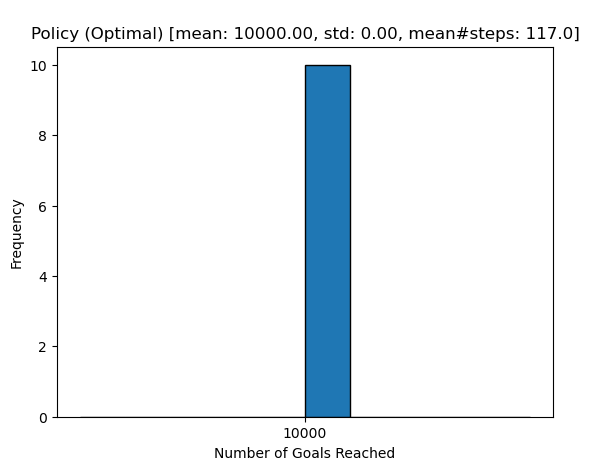

In [80]:
def check_if_terminal(st): # checks if a state is terminal it will true for goal and hole states
    for act in range(nA): # for each action 
        transitions = env_unwrapped.P[st][act]
        for (prob, nxt, rew, done) in transitions: 
            if not done: # checking if done or not
                return False
    return True

def frozenlake_value_iteration(gamma=1.0, theta=1e-04): # defining function which return the optimal policy and values
    best_values = np.zeros(nS) # first we are initialising 
    while True:
        max_diff = 0.0
        updated_values = np.copy(best_values) # creating a copy for best_values
        for s_i in range(nS): # for each state we will compute the max Q
            if not check_if_terminal(s_i): # for each non terminal state we will calculate new values
                q_list = [] # collects all the Q values
                for a_i in range(nA):
                    q_sum = 0.0
                    for (prob, nxt_state, reward, done) in env_unwrapped.P[s_i][a_i]:
                        q_sum += prob * (reward + gamma * best_values[nxt_state]) 
                    q_list.append(q_sum)
                best_val = max(q_list) # maximum Q among all actions
                updated_values[s_i] = best_val
                max_diff = max(max_diff, abs(best_val - best_values[s_i])) # absolute change from the old best_values to the new one
        best_values = updated_values # we are assigning the new values back
        if max_diff < theta: # break if we are below the threshold change
            break

    best_policy = np.zeros(nS, dtype=int)     # once the convergence is done pick the best action in each state
    for s_i in range(nS):
        if check_if_terminal(s_i):
            best_policy[s_i] = 0  # terminal value
        else:
            q_list = []
            for a_i in range(nA):
                q_sum = 0.0
                for (prob, nxt_state, reward, done) in env_unwrapped.P[s_i][a_i]:
                    q_sum += prob * (reward + gamma * best_values[nxt_state])
                q_list.append(q_sum)
            best_policy[s_i] = np.argmax(q_list)
    return best_values, best_policy

vals, pol = frozenlake_value_iteration(gamma=1.0, theta=1e-04) # running the value iteration
print("*** Optimal Policy ***\n{}".format(display_policy(pol))) # displaying the policy
print("\nFinal Values:\n{}".format(display_policy(vals))) # displaying the values
# evaluating the policy for 100 runs and 10000 episode per run by using the function from above cell repeat_runs_for_policy
goals_list, steps_list = repeat_runs_for_policy(pol, repetitions=100, episode_count=10000)
mean_goals = np.mean(goals_list)
std_goals = np.std(goals_list)
mean_steps = np.mean(steps_list) 

 # plotting histogram 
plt.hist(goals_list, bins=10, edgecolor='black', density=True)
plt.xlabel("Number of Goals Reached")
plt.ylabel("Frequency")
plt.title(f"\nPolicy (Optimal) [mean: {mean_goals:.2f}, std: {std_goals:.2f}, mean#steps: {mean_steps:.1f}]")
plt.xticks([10000])
plt.show()